# ChatBot

In [ ]:
!pip install langgraph langsmith langchain_classic langchain_community langchain_groq langchain_core pydantic chromadb langchain-tavily langchain_huggingface youtube_search wikipedia httpx langchain_google_genai streamlit transformers

In [ ]:
import os
from google.colab import userdata
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

os.environ["TAVILY_API_KEY"]= userdata.get("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"]= userdata.get("SERPER_API_KEY")

## Running .py file and Streamlit in Colab

In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 39.1 MB/s eta 0:00:00


In [ ]:
import os
from google.colab import userdata
os.environ["NGROK_AUTH_TOKEN"] = userdata.get('NGROK_AUTH_TOKEN')

In [ ]:
%%writefile app.py
import streamlit as st
st.title("Hello Streamlit on Colab!")
st.write("This app is running from a Google Colab notebook.")


Writing app.py


In [ ]:
!pip install pyngrok
from pyngrok import ngrok
# Authenticate with your token
!ngrok config add-authtoken ""
# Open a tunnel
public_url = ngrok.connect(8501)
print(f"App Link: {public_url}")
!streamlit run app.py


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
App Link: NgrokTunnel: "https://barcode-lyrics-chevron.ngrok-free.dev" -> "http://localhost:8501"


2026-05-23 21:24:12.187 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://104.197.163.74:8501



  Stopping...
  Stopping...


In [ ]:
!curl https://icanhazip.com

104.197.163.74


In [ ]:
# Install localtunnel
!npm install -g localtunnel
# Run streamlit in the background
!streamlit run app.py &>/content/logs.txt &
# Expose the port
!npx localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋⠙⠹⠸⠼⠴⠦⠧your url is: https://five-kiwis-wear.loca.lt
^C


In [ ]:
import os

try:
    from google.colab import drive, userdata
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# OpenAI Secrets
if COLAB:
    os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

# Install needed libraries in CoLab
if COLAB:
    !pip install langchain_classic langchain_groq streamlit

Note: using Google CoLab
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 37.8 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1


In [ ]:
%%writefile app1.py
import streamlit as st

st.write("Hello World")

Writing app1.py


In [ ]:
!curl https://loca.lt/mytunnelpassword

104.197.163.74

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴your url is: https://eighty-queens-prove.loca.lt
^C


## Chatbot Production

In [ ]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct")

In [ ]:
llm.invoke("hey!").content

"Hey! How's it going? Is there something I can help you with, or do you just want to chat?"

In [ ]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, Literal, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AnyMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import  ToolNode

In [ ]:
def call_model(state: MessagesState):
  messages = state['messages']
  response = llm.invoke(messages)
  return {"messages": [response]}

In [ ]:
workflow = StateGraph(MessagesState)
workflow.add_node("chatbot",call_model)

workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot", END)

app = workflow.compile()

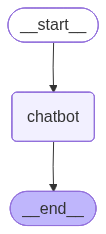

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
class MessagesState(TypedDict):
  messages: Annotated[list[AnyMessage], add_messages]

In [ ]:
input = {"messages": "Hey! My name is Yousuf."}

In [ ]:
app.invoke(input)

{'messages': [HumanMessage(content='Hey! My name is Yousuf.', additional_kwargs={}, response_metadata={}, id='cd6b55da-d971-432b-a0b6-5efbe08db204'),
  AIMessage(content="Nice to meet you, Yousuf! How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 19, 'total_tokens': 37, 'completion_time': 0.04051849, 'completion_tokens_details': None, 'prompt_time': 0.00055401, 'prompt_tokens_details': None, 'queue_time': 0.368426488, 'total_time': 0.0410725}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5826-bff8-7c03-a2ca-714ebf4e21f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 18, 'total_tokens': 37})]}

In [ ]:
for output in app.stream(input):
  for key, value in output.items():
    print(f"Output from {key} Node")
    print("-------")
    print(value)
    print("\n")

Output from chatbot Node
-------
{'messages': [AIMessage(content="Nice to meet you, Yousuf! How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 19, 'total_tokens': 37, 'completion_time': 0.040617956, 'completion_tokens_details': None, 'prompt_time': 0.000509363, 'prompt_tokens_details': None, 'queue_time': 0.865798343, 'total_time': 0.041127319}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_f0bb21cb36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5828-1957-7f30-8e37-4ff69dbe1e9e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 18, 'total_tokens': 37})]}




In [ ]:
@tool
def search(query: str):
    """this is my custom tool."""
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "It's 60 degrees and foggy."
    return "It's 90 degrees and sunny."

In [ ]:
search.invoke("What is a weather in sf?")

"It's 60 degrees and foggy."

In [ ]:
search.invoke("What is a weather in Pakistan?")

"It's 90 degrees and sunny."

In [ ]:
search

StructuredTool(name='search', description='this is my custom tool.', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x78e49881e840>)

In [ ]:
tools=[search]

In [ ]:
tool_node=ToolNode(tools)

In [ ]:
llm_with_tool=llm.bind_tools(tools)

In [ ]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm_with_tool.invoke(messages)
    return {"messages": [response]}

In [ ]:
response=call_model({"messages": ["hi how are you?"]})

In [ ]:
response

{'messages': [AIMessage(content="I'm doing well, thanks for asking! I'm a large language model, so I don't have feelings like humans do, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 708, 'total_tokens': 759, 'completion_time': 0.116073689, 'completion_tokens_details': None, 'prompt_time': 0.026002843, 'prompt_tokens_details': None, 'queue_time': 0.052406577, 'total_time': 0.142076532}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5834-4dce-7812-aed0-b469897926ec-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 708, 'output_tokens': 51, 'total_tokens': 759})]}

In [ ]:
messages = response["messages"]

In [ ]:
last_message = messages[-1]

In [ ]:
last_message

AIMessage(content="I'm doing well, thanks for asking! I'm a large language model, so I don't have feelings like humans do, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 708, 'total_tokens': 759, 'completion_time': 0.116073689, 'completion_tokens_details': None, 'prompt_time': 0.026002843, 'prompt_tokens_details': None, 'queue_time': 0.052406577, 'total_time': 0.142076532}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5834-4dce-7812-aed0-b469897926ec-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 708, 'output_tokens': 51, 'total_tokens': 759})

In [ ]:
response = call_model({"messages": "What is the weather in Pakistan?"})

In [ ]:
response

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'a23sxx1ev', 'function': {'arguments': '{"query":"Pakistan weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 710, 'total_tokens': 739, 'completion_time': 0.065484621, 'completion_tokens_details': None, 'prompt_time': 0.030719087, 'prompt_tokens_details': None, 'queue_time': 0.294662572, 'total_time': 0.096203708}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5834-d057-7901-ab5e-e7f485dd4ac1-0', tool_calls=[{'name': 'search', 'args': {'query': 'Pakistan weather'}, 'id': 'a23sxx1ev', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 710, 'output_tokens': 29, 'total_tokens': 739})]}

In [ ]:
messages = response["messages"]

In [ ]:
last_message = messages[-1]

In [ ]:
messages

[AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'a23sxx1ev', 'function': {'arguments': '{"query":"Pakistan weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 710, 'total_tokens': 739, 'completion_time': 0.065484621, 'completion_tokens_details': None, 'prompt_time': 0.030719087, 'prompt_tokens_details': None, 'queue_time': 0.294662572, 'total_time': 0.096203708}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5834-d057-7901-ab5e-e7f485dd4ac1-0', tool_calls=[{'name': 'search', 'args': {'query': 'Pakistan weather'}, 'id': 'a23sxx1ev', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 710, 'output_tokens': 29, 'total_tokens': 739})]

In [ ]:
last_message.tool_calls

[{'name': 'search',
  'args': {'query': 'Pakistan weather'},
  'id': 'a23sxx1ev',
  'type': 'tool_call'}]

In [ ]:
def router_function(state: MessagesState) -> Literal["tools", END]:
  #print(f"here is a state from should continue {state}")
  messages = state["messages"]
  last_message = messages[-1]
  #print(f"here is a last message from should continue {last_message}")
  if last_message.tool_calls:
    return "tools"
  return END

In [ ]:
# Define a new graph
workflow2 = StateGraph(MessagesState)

workflow2.add_node("agent", call_model)
workflow2.add_node("tools", tool_node)

workflow2.add_edge(START, "agent")
workflow2.add_conditional_edges("agent", router_function, {"tools": "tools", END: END})

app2 = workflow2.compile()

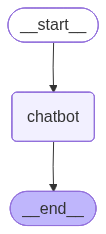

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
app.invoke({"messages": ["hi how are you?"]})

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='50d01434-2aee-4402-8e45-c77b3aa9c351'),
  AIMessage(content="I'm doing well, thanks for asking! I'm a large language model, so I don't have emotions like humans do, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 15, 'total_tokens': 71, 'completion_time': 0.126280971, 'completion_tokens_details': None, 'prompt_time': 0.000876427, 'prompt_tokens_details': None, 'queue_time': 0.276421502, 'total_time': 0.127157398}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5837-35c8-76a2-9c46-3198c41e86a9-0', tool_calls=[], invalid_tool_calls=

In [ ]:
app.invoke({"messages": ["What is the weather in San Francisco?"]})

{'messages': [HumanMessage(content='What is the weather in San Francisco?', additional_kwargs={}, response_metadata={}, id='5f5aa218-68c8-496b-bdc7-ecc447b59040'),
  AIMessage(content="San Francisco! Known for its iconic fog, cool summers, and mild winters. The weather in San Francisco can be quite unpredictable, but here's a general idea of what you can expect:\n\n**Current Weather:**\nI'd be happy to provide you with the current weather conditions in San Francisco. However, I'm a large language model, I don't have real-time access to current weather conditions. For the most up-to-date and accurate information, I recommend checking a reliable weather website or app, such as:\n\n* National Weather Service (NWS): weather.gov\n* AccuWeather: accuweather.com\n* Weather.com: weather.com\n\n**Typical Weather Patterns:**\n\n* **Summer (June to August):** Cool and foggy, with average highs around 67°F (19°C) and lows around 54°F (12°C).\n* **Fall (September to November):** Mild and sunny, wit

In [ ]:
workflow2.add_edge("tools", "agent")

In [ ]:
app2 = workflow2.compile()

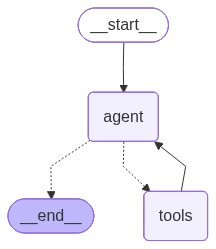

In [ ]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [ ]:
for output in app2.stream({"messages": ["What is the weather in San Francisco?"]}):
  for key, value in output.items():
    print(f"Here is output from {key}")
    print("________________")
    print(value)
    print("\n")

Here is output from agent
________________
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ehd5k1brf', 'function': {'arguments': '{"query":"San Francisco weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 711, 'total_tokens': 741, 'completion_time': 0.067939292, 'completion_tokens_details': None, 'prompt_time': 0.025147717, 'prompt_tokens_details': None, 'queue_time': 0.385473102, 'total_time': 0.093087009}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5837-7d53-75a2-98b6-c3791f238027-0', tool_calls=[{'name': 'search', 'args': {'query': 'San Francisco weather'}, 'id': 'ehd5k1brf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 711, 'output_tokens': 30, 'total_tokens': 741})]}


In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [ ]:
# Define a new graph
workflow3 = StateGraph(MessagesState)

workflow3.add_node("agent", call_model)
workflow3.add_node("tools", tool_node)

workflow3.add_edge(START, "agent")
workflow3.add_conditional_edges("agent", router_function, {"tools": "tools", END: END})
workflow3.add_edge("tools", "agent")


In [ ]:
app3 = workflow3.compile(checkpointer=memory)

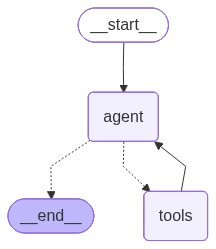

In [ ]:
from IPython.display import Image, display

try:
    display(Image(app3.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
config = {"configurable": {"thread_id": "1"}}

In [ ]:
events = app3.stream(
    {"messages": ["Hi, my name is Yousuf."]}, config, stream_mode="values"
)

In [ ]:
for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Yousuf.
================================== Ai Message ==================================

Hello Yousuf! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [ ]:
events = app3.stream(
    {"messages": ["Can you tell me what is my name?"]}, config, stream_mode="values"
)

In [ ]:
for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

Can you tell me what is my name?
================================== Ai Message ==================================

Your name is Yousuf.


In [ ]:
memory.get(config)

{'v': 4,
 'ts': '2026-05-24T04:23:24.366785+00:00',
 'id': '1f157284-df8f-6eb2-8004-ddb43bb4b7ce',
 'channel_versions': {'__start__': '00000000000000000000000000000005.0.768342722018648',
  'messages': '00000000000000000000000000000006.0.5406264904460812',
  'branch:to:agent': '00000000000000000000000000000006.0.5406264904460812'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000004.0.823884242549913'},
  'agent': {'branch:to:agent': '00000000000000000000000000000005.0.768342722018648'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='Hi, my name is Yousuf.', additional_kwargs={}, response_metadata={}, id='404e0065-fbd3-4532-87c2-7e8e4fb8d2ad'),
   AIMessage(content="Hello Yousuf! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 712, 'total_tokens': 739, 'com

# Chatbot from .py Scripts

In [ ]:
%%writefile bot.py

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, Literal, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AnyMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import  ToolNode
from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults

class chatbot:
  def __init__(self):
    self.llm=ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct")

  def call_tool(self):
    tool = TavilySearchResults(max_results=2)
    tools = [tool]
    self.tool_node = ToolNode(tools=[tool])
    self.llm_with_tool=self.llm.bind_tools(tools)

  def call_model(self, state: MessagesState):
    messages = state['messages']
    response = self.llm_with_tool.invoke(messages)
    return {"messages": [response]}


  def router_function(self, state: MessagesState) -> Literal["tools", END]:
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
      return "tools"
    return END

  def __call__(self):
    self.call_tool()
    workflow = StateGraph(MessagesState)
    workflow.add_node("agent", self.call_model)
    workflow.add_node("tools", self.tool_node)
    workflow.add_edge(START, "agent")
    workflow.add_conditional_edges("agent", self.router_function, {"tools": "tools", END: END})
    workflow.add_edge("tools", "agent")
    self.app = workflow.compile()
    return self.app





Overwriting bot.py


In [ ]:
%%writefile app2.py

from bot import chatbot

mybot=chatbot()
workflow=mybot()
response = workflow.invoke({"messages": ["Who is the current Vice President of the United States of America?"]})
print(response["messages"][-1].content)
print("Hello")

Writing app2.py


In [ ]:
%%writefile app3.py

print("Hello I am here!")

Writing app3.py


In [ ]:
%run app3.py

Hello I am here!


In [ ]:
%run app2.py

/content/bot.py:17: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2)


The current Vice President of the United States of America is JD Vance.
Hello


In [ ]:
!curl https://loca.lt/mytunnelpassword

34.87.156.242

In [ ]:
!python run app3.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦your url is: https://soft-parents-mate.loca.lt
^C


In [ ]:
%%writefile app4.py

import streamlit as st
from transformers import pipeline
from bot import chatbot

mybot=chatbot()
workflow=mybot()

# Set up the Streamlit app UI
st.title("ChatBot with LangGraph")
st.write("Ask any question, and I'll try to answer it!")

# Input text box for the question
question = st.text_input("Enter your question here:")
input={"messages": [question]}

# Button to get the answer
if st.button("Get Answer"):
    if input:
        response=workflow.invoke(input)
        st.write("**Answer:**", response['messages'][-1].content)
    else:
        st.warning("Please enter a question to get an answer.")

# Additional styling (optional)
st.markdown("---")
st.caption("Powered by Streamlit and Transformers")



Overwriting app4.py


In [ ]:
%%writefile app5.py
import streamlit as st

st.write("Hello World")

Overwriting app5.py


In [ ]:
!curl https://loca.lt/mytunnelpassword

34.87.156.242

In [ ]:
!streamlit run app4.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://legal-parents-hammer.loca.lt
^C


# Another Streamlit Experiment

In [ ]:
!pip install -q streamlit
!npm install -g localtunnel


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 2s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

In [ ]:
%%writefile app6.py
import streamlit as st

st.title("My Colab Streamlit App")

# Use st.text_input to capture user data
user_name = st.text_input("Enter your name:", "Guest")

if user_name:
    st.write(f"Hello, {user_name}!")


Overwriting app6.py


In [ ]:
!curl ipv4.icanhazip.com


34.87.156.242


In [ ]:
!streamlit run app6.py & npx localtunnel --port 8501


⠙⠹

⠸⠼⠴⠦⠧⠇⠏your url is: https://old-swans-retire.loca.lt
2026-05-24 05:12:07.704 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.156.242:8501

  Stopping...
^C


In [ ]:
%%writefile app7.py

import streamlit as st
st.write('# Streamlit calculator')
number1= st.number_input('number 1')
number2 = st.number_input('number 2')
num3 = number1+number2
st.write('# Answer is ',num3)

Writing app7.py


In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.87.156.242


In [ ]:
! streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://ninety-impalas-stay.loca.lt
2026-05-24 05:21:43.128 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.156.242:8501

